In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
import mlflow
import mlflow.lightgbm
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

df = pd.read_parquet('../data/processed/features.parquet')
print("Shape:", df.shape)
df.head()

c:\Users\rushi\supply_chain_decision_system\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Shape: (405058, 31)


,Store,DayOfWeek,Date,Sales,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,...,sales_lag_21,sales_lag_28,sales_rolling_mean_7,sales_rolling_std_7,sales_rolling_mean_14,sales_rolling_std_14,sales_rolling_mean_28,sales_rolling_std_28,Promo_DayOfWeek,StoreType_Promo
0,2,0,2013-02-04,6480,1,0,0,0,0,570.0,...,5618.0,4422.0,3643.142857,868.523158,4222.142857,1289.831525,4381.142857,1338.821586,0,0
1,2,1,2013-02-05,6269,1,0,0,0,0,570.0,...,4810.0,4159.0,4253.857143,1147.075619,4439.214286,1399.332378,4454.642857,1396.400617,1,0
2,2,2,2013-02-06,6438,1,0,0,0,0,570.0,...,2630.0,4484.0,4642.428571,1316.672429,4715.642857,1346.550214,4530.000000,1436.220864,2,0
3,2,3,2013-02-07,5575,1,0,0,0,0,570.0,...,3995.0,2342.0,5067.714286,1351.788040,4724.714286,1358.499309,4599.785714,1480.686862,3,0
4,2,4,2013-02-08,4203,1,0,0,0,0,570.0,...,4075.0,6775.0,5229.000000,1332.460381,4708.428571,1345.886537,4715.250000,1423.036103,4,0


In [2]:
TARGET = 'Sales'

# Columns to exclude from features
EXCLUDE = ['Store', 'Date', 'Sales']

FEATURE_COLS = [c for c in df.columns if c not in EXCLUDE]
print(f"Features ({len(FEATURE_COLS)}):")
print(FEATURE_COLS)

Features (28):
['DayOfWeek', 'Promo', 'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment', 'CompetitionDistance', 'Promo2', 'CompetitionOpenMonths', 'Month', 'Year', 'WeekOfYear', 'DayOfMonth', 'IsWeekend', 'DaysToMonthEnd', 'Promo2Active', 'sales_lag_7', 'sales_lag_14', 'sales_lag_21', 'sales_lag_28', 'sales_rolling_mean_7', 'sales_rolling_std_7', 'sales_rolling_mean_14', 'sales_rolling_std_14', 'sales_rolling_mean_28', 'sales_rolling_std_28', 'Promo_DayOfWeek', 'StoreType_Promo']


In [3]:
def mape(y_true, y_pred):
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def evaluate(y_true, y_pred):
    return {
        'MAPE': round(mape(y_true, y_pred), 4),
        'RMSE': round(rmse(y_true, y_pred), 4),
        'MAE': round(mae(y_true, y_pred), 4)
    }

In [4]:
# Baseline: predict next week = same day last week (lag_7)
df_sorted = df.sort_values(['Store', 'Date'])

baseline_preds = df_sorted['sales_lag_7'].values
baseline_actuals = df_sorted[TARGET].values

baseline_metrics = evaluate(baseline_actuals, baseline_preds)
print("Naive baseline (predict = sales 7 days ago):")
print(baseline_metrics)
print("\nThis is the benchmark your model must beat.")

Naive baseline (predict = sales 7 days ago):
{'MAPE': np.float64(38.3487), 'RMSE': np.float64(2996.4479), 'MAE': np.float64(2320.2335)}

This is the benchmark your model must beat.


In [5]:
df['Date'] = pd.to_datetime(df['Date'])
dates = sorted(df['Date'].unique())
total_days = len(dates)

n_splits = 5
fold_size = total_days // (n_splits + 1)
gap_days = 7
forecast_horizon = 42

print(f"Total unique dates: {total_days}")
print(f"Fold size: {fold_size} days")
print(f"Forecast horizon: {forecast_horizon} days")
print(f"Gap between train and test: {gap_days} days\n")

fold_results = []

for i in range(n_splits):
    train_end_idx = fold_size * (i + 1)
    test_start_idx = train_end_idx + gap_days
    test_end_idx = test_start_idx + forecast_horizon

    if test_end_idx > total_days:
        break

    train_end = dates[train_end_idx]
    test_start = dates[test_start_idx]
    test_end = dates[min(test_end_idx, total_days - 1)]

    train = df[df['Date'] <= train_end]
    test = df[(df['Date'] >= test_start) & (df['Date'] <= test_end)]

    X_train = train[FEATURE_COLS]
    y_train = train[TARGET]
    X_test = test[FEATURE_COLS]
    y_test = test[TARGET]

    model = lgb.LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        random_state=42,
        verbose=-1
    )
    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        callbacks=[lgb.early_stopping(50, verbose=False),
                   lgb.log_evaluation(period=-1)]
    )

    preds = model.predict(X_test)
    metrics = evaluate(y_test.values, preds)
    metrics['fold'] = i + 1
    metrics['train_size'] = len(train)
    metrics['test_size'] = len(test)
    fold_results.append(metrics)

    print(f"Fold {i+1}: train up to {train_end.date()} | "
          f"test {test_start.date()} → {test_end.date()} | "
          f"MAPE: {metrics['MAPE']:.2f}%")

results_df = pd.DataFrame(fold_results)
print(f"\nAverage across folds:")
print(results_df[['MAPE','RMSE','MAE']].mean().round(4))

Total unique dates: 914
Fold size: 152 days
Forecast horizon: 42 days
Gap between train and test: 7 days

Fold 1: train up to 2013-06-30 | test 2013-07-07 → 2013-08-18 | MAPE: 12.02%
Fold 2: train up to 2013-11-29 | test 2013-12-06 → 2014-01-17 | MAPE: 24.20%
Fold 3: train up to 2014-04-30 | test 2014-05-07 → 2014-06-18 | MAPE: 12.75%
Fold 4: train up to 2014-09-29 | test 2014-10-06 → 2014-11-17 | MAPE: 9.94%
Fold 5: train up to 2015-02-28 | test 2015-03-07 → 2015-04-18 | MAPE: 11.52%

Average across folds:
MAPE      14.0879
RMSE    1229.1031
MAE      875.4656
dtype: float64


In [6]:
avg_mape = results_df['MAPE'].mean()
baseline_mape = baseline_metrics['MAPE']

print(f"Baseline MAPE: {baseline_mape:.2f}%")
print(f"LightGBM MAPE: {avg_mape:.2f}%")
print(f"Improvement: {baseline_mape - avg_mape:.2f} percentage points")

if avg_mape < baseline_mape:
    print("✓ Model beats the naive baseline")
else:
    print("✗ Model does NOT beat baseline — something is wrong")

Baseline MAPE: 38.35%
LightGBM MAPE: 14.09%
Improvement: 24.26 percentage points
✓ Model beats the naive baseline


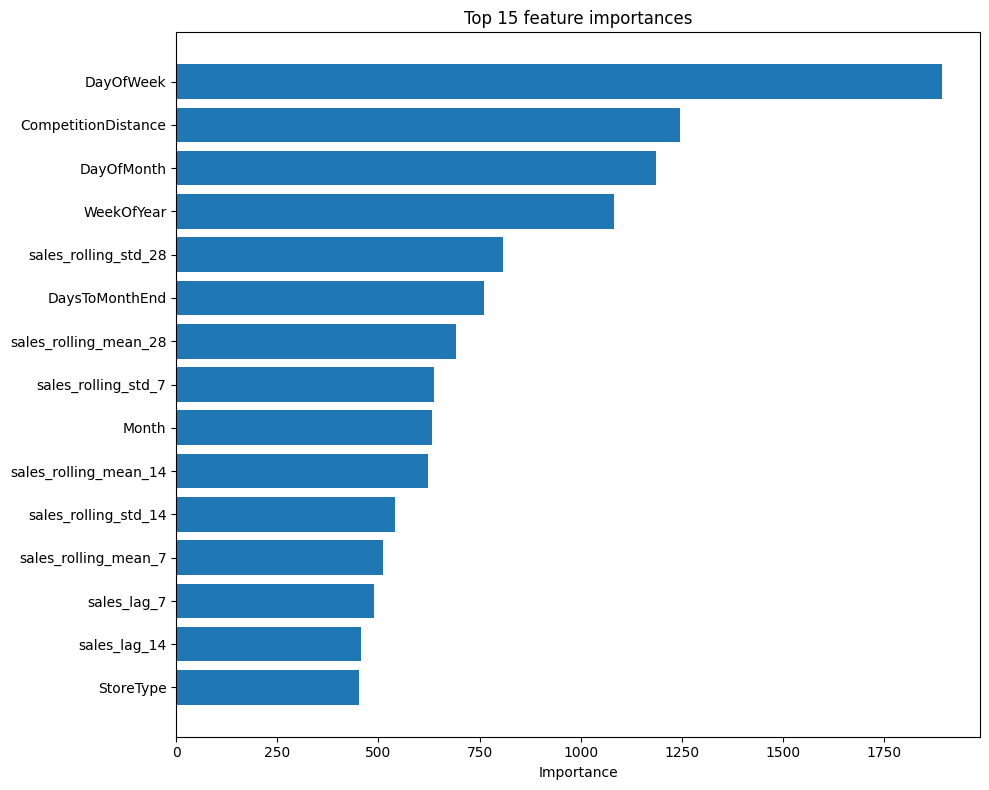

                  feature  importance
0               DayOfWeek        1893
6     CompetitionDistance        1246
12             DayOfMonth        1186
11             WeekOfYear        1082
25   sales_rolling_std_28         808
14         DaysToMonthEnd         760
24  sales_rolling_mean_28         693
21    sales_rolling_std_7         638
9                   Month         632
22  sales_rolling_mean_14         623


In [7]:
# Train on full data for feature importance
X_full = df[FEATURE_COLS]
y_full = df[TARGET]

final_model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    verbose=-1
)
final_model.fit(X_full, y_full)

importance = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importance': final_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(importance['feature'][:15], importance['importance'][:15])
plt.title('Top 15 feature importances')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(importance.head(10))

Using store 2


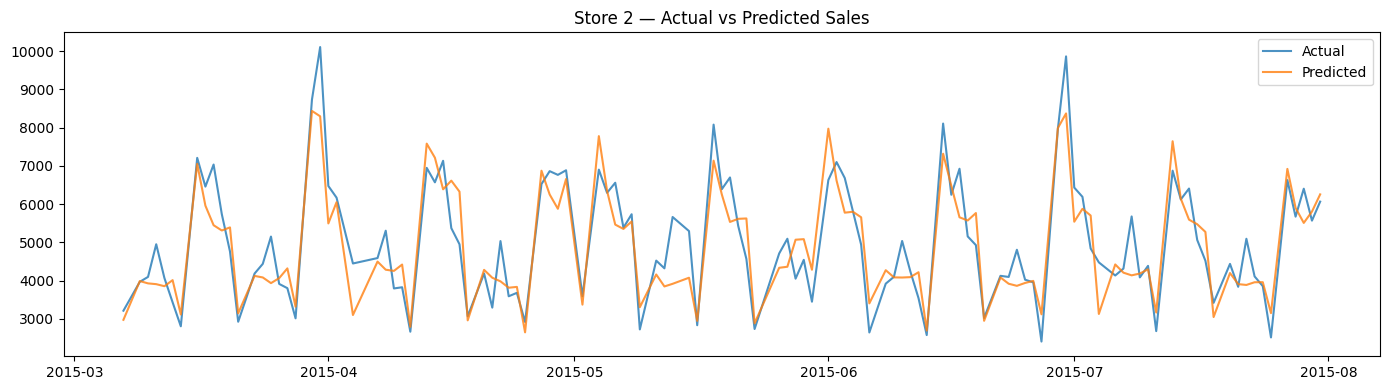

In [9]:
# Find a store that has data in the test period
available_stores = last_test['Store'].unique()
store_id = available_stores[0]
print(f"Using store {store_id}")

store_test = last_test[last_test['Store'] == store_id].copy()
store_test['predicted'] = m.predict(store_test[FEATURE_COLS])

plt.figure(figsize=(14, 4))
plt.plot(store_test['Date'], store_test['Sales'], label='Actual', alpha=0.8)
plt.plot(store_test['Date'], store_test['predicted'], label='Predicted', alpha=0.8)
plt.title(f'Store {store_id} — Actual vs Predicted Sales')
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
import joblib
import os

os.makedirs('../models', exist_ok=True)
joblib.dump(final_model, '../models/lgbm_model.pkl')
joblib.dump(FEATURE_COLS, '../models/feature_cols.pkl')
print("Model saved to models/lgbm_model.pkl")

Model saved to models/lgbm_model.pkl


In [12]:
# Overfitting check — compare train error vs test error
train_preds = m.predict(X_last)
train_metrics = evaluate(y_last.values, train_preds)

# Test error from fold results
avg_test_mape = results_df['MAPE'].mean()

print(f"Train MAPE: {train_metrics['MAPE']:.2f}%")
print(f"Test MAPE (avg across folds): {avg_test_mape:.2f}%")
print(f"Gap: {avg_test_mape - train_metrics['MAPE']:.2f} percentage points")
print()
if avg_test_mape - train_metrics['MAPE'] < 5:
    print("✓ Small gap — model generalizes well, no significant overfitting")
elif avg_test_mape - train_metrics['MAPE'] < 15:
    print("⚠ Moderate gap — some overfitting, consider regularization")
else:
    print("✗ Large gap — model is overfitting significantly")

Train MAPE: 9.37%
Test MAPE (avg across folds): 14.09%
Gap: 4.72 percentage points

✓ Small gap — model generalizes well, no significant overfitting


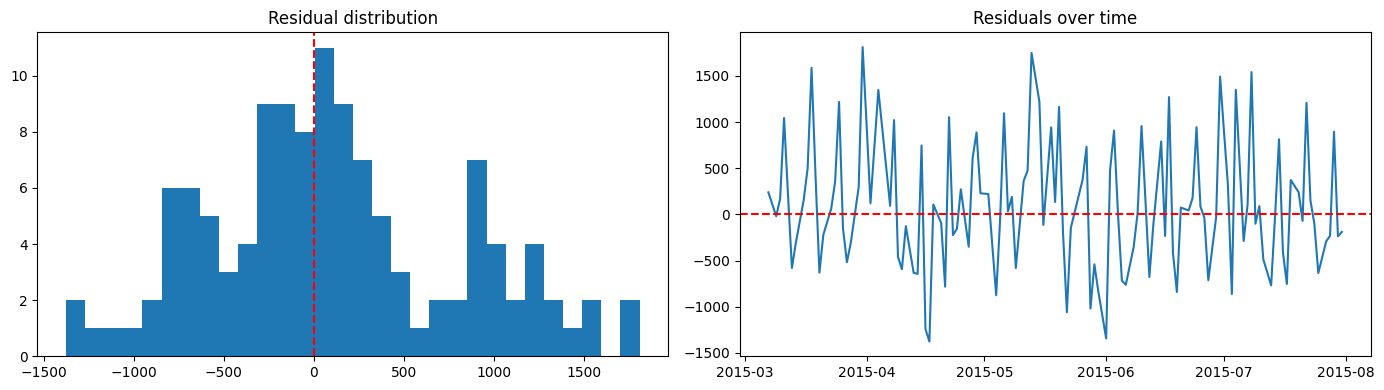

Mean residual: 108.18 (should be near 0)
Std residual: 698.49


In [13]:
store_test['residual'] = store_test['Sales'] - store_test['predicted']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(store_test['residual'], bins=30)
axes[0].set_title('Residual distribution')
axes[0].axvline(0, color='red', linestyle='--')

axes[1].plot(store_test['Date'], store_test['residual'])
axes[1].set_title('Residuals over time')
axes[1].axhline(0, color='red', linestyle='--')

plt.tight_layout()
plt.show()

print(f"Mean residual: {store_test['residual'].mean():.2f} (should be near 0)")
print(f"Std residual: {store_test['residual'].std():.2f}")

In [14]:
# Stockout risk: model predicted less than actual — store would have ordered too little
store_test['stockout_risk'] = store_test['predicted'] < store_test['Sales']
store_test['overstock'] = store_test['predicted'] > store_test['Sales'] * 1.2

print(f"Days with stockout risk: {store_test['stockout_risk'].sum()} "
      f"({store_test['stockout_risk'].mean()*100:.1f}%)")
print(f"Days with overstock risk: {store_test['overstock'].sum()} "
      f"({store_test['overstock'].mean()*100:.1f}%)")
print(f"\nThis directly feeds into the reorder decision engine")

Days with stockout risk: 64 (52.9%)
Days with overstock risk: 11 (9.1%)

This directly feeds into the reorder decision engine


In [15]:
# Analyze residuals by promo vs non-promo days
store_test_full = last_test[last_test['Store'] == store_id].copy()
store_test_full['predicted'] = m.predict(store_test_full[FEATURE_COLS])
store_test_full['residual'] = store_test_full['Sales'] - store_test_full['predicted']
store_test_full['abs_error'] = store_test_full['residual'].abs()

print("Average absolute error by promo:")
print(store_test_full.groupby('Promo')['abs_error'].mean().round(2))

print("\nAverage absolute error by day of week:")
print(store_test_full.groupby('DayOfWeek')['abs_error'].mean().round(2))

Average absolute error by promo:
Promo
0    469.78
1    644.50
Name: abs_error, dtype: float64

Average absolute error by day of week:
DayOfWeek
0     417.89
1     420.30
2    1080.87
3     308.89
4     585.97
5     444.20
Name: abs_error, dtype: float64
